<a href="https://colab.research.google.com/github/sanjana05111/NeuroNexus/blob/main/TITANIC_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Data Shape: (418, 12)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters Found:
 {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Model Evaluation After Tuning:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Confusion Matrix:
 [[50  0]
 [ 0 34]]

Cross-Validation Accuracy (Best Model): 1.0000
Standard Deviation: 0.0000


<ipython-input-3-cb8c00ed1bce>:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


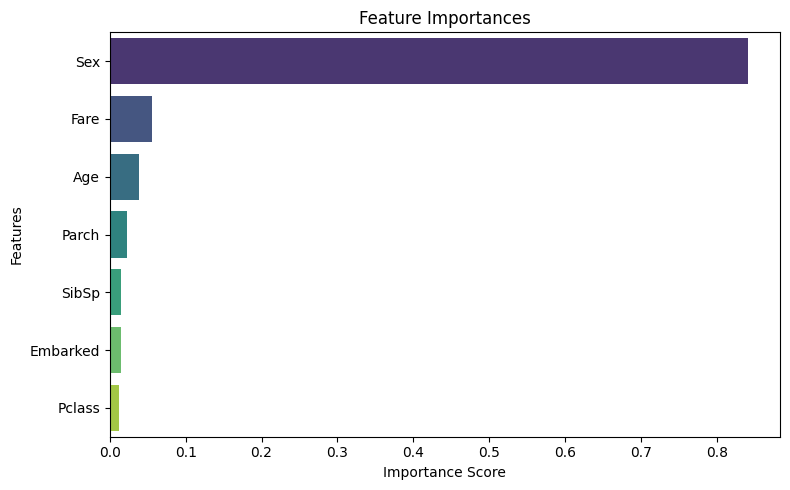

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("/content/tested[2].csv")
print("Initial Data Shape:", df.shape)

df = df.copy()

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])

le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

le_embarked = LabelEncoder()
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print("\nBest Parameters Found:\n", grid_search.best_params_)

y_pred = best_model.predict(X_val)
print("\nModel Evaluation After Tuning:")
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

cv_scores = cross_val_score(best_model, X, y, cv=5)
print(f"\nCross-Validation Accuracy (Best Model): {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

feature_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()



In [4]:
# Get user input
pclass = int(input("Pclass (1=1st, 2=2nd, 3=3rd): "))
sex = input("Sex (male/female): ").strip().lower()
age = float(input("Age: "))
sibsp = int(input("Siblings/Spouses Aboard (SibSp): "))
parch = int(input("Parents/Children Aboard (Parch): "))
fare = float(input("Fare paid: "))
embarked = input("Embarked (C/Q/S): ").strip().upper()

# Encode input features
sex_encoded = le_sex.transform([sex])[0]
embarked_encoded = le_embarked.transform([embarked])[0]

# Create input DataFrame
input_data = pd.DataFrame([{
    'Pclass': pclass,
    'Sex': sex_encoded,
    'Age': age,
    'SibSp': sibsp,
    'Parch': parch,
    'Fare': fare,
    'Embarked': embarked_encoded
}])

# Make prediction using tuned model
prediction = best_model.predict(input_data)[0]
outcome = "Survived" if prediction == 1 else "Did NOT Survive"
print(f"\nPrediction: The passenger would have **{outcome}**.")


Pclass (1=1st, 2=2nd, 3=3rd): 3
Sex (male/female): male
Age: 68
Siblings/Spouses Aboard (SibSp): 0
Parents/Children Aboard (Parch): 0
Fare paid: 7.25
Embarked (C/Q/S): c

Prediction: The passenger would have **Did NOT Survive**.
